In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import umap
import joblib
from lightgbm import LGBMClassifier 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,roc_auc_score, confusion_matrix, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
scale=StandardScaler()


2026-05-28 17:57:34.001326: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
#import dataframe
df_modelling=pd.read_parquet("../df_modelling.parquet")


In [3]:
df_modelling

,Stock_Date,Closing Price($),relative difference,comment_published_at_YMD,number_of_comments_at_date,comment_likes_agg,comment_embeddings_agg,comment_sentiment_agg,sentiment_tensor,videos_text_embeddings,Difference,videos_text_embeddings_window,TargetVariable:Up/Down,Closing Price($) lag1,relative difference lag1,Calendar_Diff_Days
0,2023-09-08 00:00:00-04:00,248.500000,-0.011889,2023-09-07 20:00:00-04:00,7.0,23.0,"[0.0008370536, -0.014247349, -0.01007516, -0.0...",-0.204929,0.000000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0 days 04:00:00,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,251.490005,-0.001707,1
1,2023-09-11 00:00:00-04:00,273.579987,0.100925,2023-09-10 20:00:00-04:00,6.0,6.0,"[0.0029067993, -0.017862955, -0.009114583, -0....",-0.239927,0.000000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0 days 04:00:00,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,248.500000,-0.011889,1
2,2023-09-12 00:00:00-04:00,267.480011,-0.022297,2023-09-11 20:00:00-04:00,17.0,130.0,"[-0.008398617, -0.0060580196, -0.010175817, -0...",0.249340,0.133205,"[0.032226562, 0.06591797, -0.00982666, 0.02087...",0 days 04:00:00,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,273.579987,0.100925,1
3,2023-09-13 00:00:00-04:00,271.299988,0.014281,2023-09-12 20:00:00-04:00,10.0,20.0,"[-0.014494324, -0.0071411133, -0.010275269, -0...",0.136969,0.000000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0 days 04:00:00,"[0.0107421875, 0.021972656, -0.0032755535, 0.0...",1,267.480011,-0.022297,1
4,2023-09-14 00:00:00-04:00,276.040009,0.017472,2023-09-13 20:00:00-04:00,8.0,7.0,"[0.0016326904, -0.016928673, -0.010227203, -0....",-0.046284,0.000000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0 days 04:00:00,"[0.0107421875, 0.021972656, -0.0032755535, 0.0...",1,271.299988,0.014281,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
485,2025-10-24 00:00:00-04:00,433.720001,-0.033988,2025-10-23 20:00:00-04:00,5.0,0.0,"[0.012046814, -0.024713134, -0.010980224, 0.03...",0.471151,0.000000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0 days 04:00:00,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,448.980011,0.022803,1
486,2025-10-27 00:00:00-04:00,452.420013,0.043115,2025-10-26 20:00:00-04:00,2.0,0.0,"[0.019599915, 0.0065307617, -0.011688232, 0.03...",0.083959,0.000000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0 days 04:00:00,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,433.720001,-0.033988,1
487,2025-10-28 00:00:00-04:00,460.549988,0.017970,2025-10-27 20:00:00-04:00,3.0,1.0,"[0.007751465, -0.010945638, -0.010498047, 0.02...",0.461608,0.000000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0 days 04:00:00,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,452.420013,0.043115,1
488,2025-10-29 00:00:00-04:00,461.510010,0.002085,2025-10-28 20:00:00-04:00,3.0,0.0,"[-0.0009358724, -0.009348552, -0.008412679, 0....",0.217439,0.000000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0 days 04:00:00,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,460.549988,0.017970,1


In [4]:
numerical_columns=['Closing Price($) lag1',
'relative difference lag1',
         'number_of_comments_at_date',
    'comment_likes_agg',
    'comment_sentiment_agg',
     'sentiment_tensor']
print(df_modelling.columns)


#concating the embeddings separately
df_modelling['embeddings_vector']=df_modelling.apply(lambda row: np.concatenate((row['comment_embeddings_agg'], row['videos_text_embeddings_window'])), axis=1)


Index(['Stock_Date', 'Closing Price($)', 'relative difference',
       'comment_published_at_YMD', 'number_of_comments_at_date',
       'comment_likes_agg', 'comment_embeddings_agg', 'comment_sentiment_agg',
       'sentiment_tensor', 'videos_text_embeddings', 'Difference',
       'videos_text_embeddings_window', 'TargetVariable:Up/Down',
       'Closing Price($) lag1', 'relative difference lag1',
       'Calendar_Diff_Days'],
      dtype='object')


In [5]:
x=df_modelling['embeddings_vector'][0]
print(f"Shape of the market vector {x.shape}")

Shape of the market vector (512,)


In [6]:
#quite balanced dataset
df_modelling['TargetVariable:Up/Down'].value_counts()

TargetVariable:Up/Down
1    249
0    241
Name: count, dtype: int64

In [7]:
def get_class_report_auc_log_reg(X,model):
    y = df_modelling['TargetVariable:Up/Down'].values

    #creating the splits for train & test
    split_at_train=int(X.shape[0]*0.7)
    split_at_val=int(X.shape[0]*0.9)
    X_train=X[:split_at_train]
    X_val=X[split_at_train:split_at_val]
    X_test=X[split_at_val:]
    y_train=y[:split_at_train]
    y_val=y[split_at_train:split_at_val]
    y_test=y[split_at_val:]

    #scaling
    X_train = scale.fit_transform(X_train)
    X_val   = scale.transform(X_val)
    X_test  = scale.transform(X_test)

    #creating baseline model: logistic regression
    model.fit(X_train, y_train)
    #no need for outputing the model's coefficent because we have 500 columns
    y_prob=model.predict_proba(X_test)[:,1]
    y_pred=model.predict(X_test)
    print(classification_report(y_test, y_pred))
    auc=roc_auc_score(y_test, y_prob)

    cm=confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["True 0", "True 1"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)



    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')  # random line
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right',bbox_to_anchor=(1,-0.2), facecolor='none')
    plt.title("ROC for Logistic Regression")
    #plt.savefig(f"ROC curve {str(text)}.png", bbox_inches='tight', transparent=True)
    plt.show()
    #predicting all rows
    y_pred_all=model.predict(X)
    return y_pred_all, model



(490, 6)
Logistic Regression with numerical values only (6)
              precision    recall  f1-score   support

           0       0.40      0.95      0.57        20
           1       0.50      0.03      0.06        29

    accuracy                           0.41        49
   macro avg       0.45      0.49      0.32        49
weighted avg       0.46      0.41      0.27        49



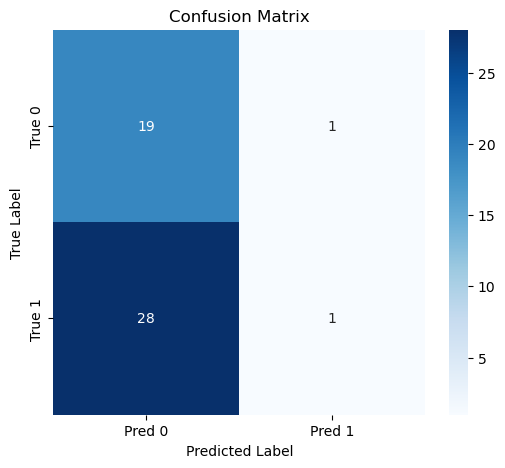

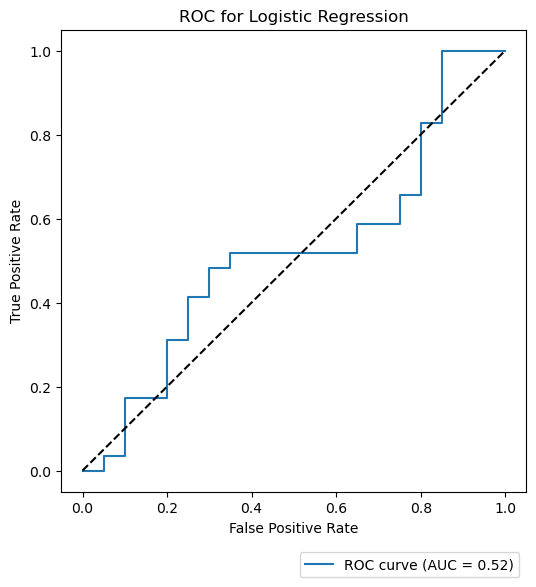

: 

In [ ]:
#Logistic Regression with numerical values only
# Stack the market vectors into a 2D array 
numerical_values=np.stack(df_modelling[numerical_columns].values)
X = numerical_values #np.concatenate((numerical_values, Embeddings_reduced), axis=1)
print(X.shape)
print("Logistic Regression with numerical values only (6)")
y_pred, model=get_class_report_auc_log_reg(X, LogisticRegression())

Experimenting with Dimensionality Reduction (UMAP):

In [ ]:
#modelling with embeddings only reduced to 6 dimensions
#initalizing umap
reducer=umap.UMAP(n_components=3, n_jobs=-1)
#reducing components
embeddings_array=np.stack(df_modelling['embeddings_vector'])
Embeddings_reduced=reducer.fit_transform(embeddings_array)
X =Embeddings_reduced
print(X.shape)
print("Logistic Regression only with embeddings reduced to 3 components")
y_pred, model=get_class_report_auc_log_reg(X, LogisticRegression())

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


(490, 6)
Logistic regression with embeddings only reduced to 3 components
              precision    recall  f1-score   support

           0       0.45      0.67      0.54        43
           1       0.59      0.36      0.45        55

    accuracy                           0.50        98
   macro avg       0.52      0.52      0.50        98
weighted avg       0.53      0.50      0.49        98



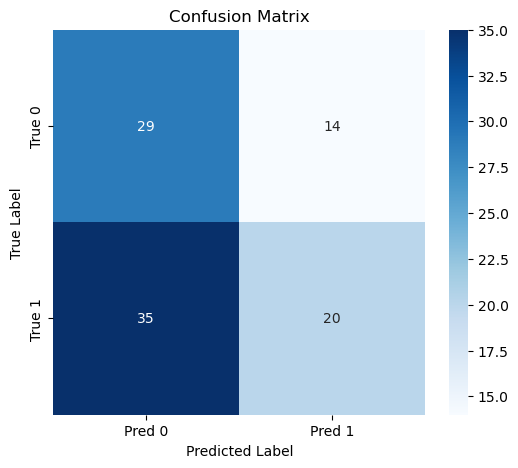

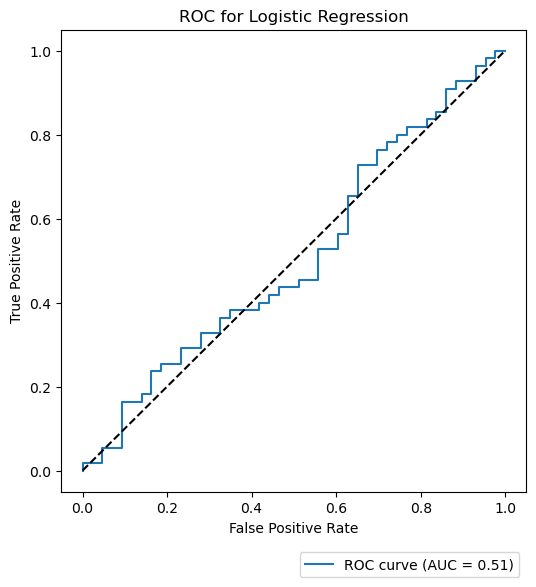

In [ ]:
#modelling with embeddings only reduced to 3 dimensions
#initalizing umap
reducer=umap.UMAP(n_components=6, n_jobs=-1)
#reducing components
embeddings_array=np.stack(df_modelling['embeddings_vector'])
Embeddings_reduced=reducer.fit_transform(embeddings_array)
X =Embeddings_reduced
print(X.shape)
print("Logistic regression with embeddings only reduced to 3 components") 
y_pred=get_class_report_auc_log_reg(X, LogisticRegression())

(490, 12)
Logistic Regression with embeddings reduced to 6 components and 6 numerical columns
              precision    recall  f1-score   support

           0       0.44      0.91      0.59        43
           1       0.56      0.09      0.16        55

    accuracy                           0.45        98
   macro avg       0.50      0.50      0.37        98
weighted avg       0.50      0.45      0.35        98



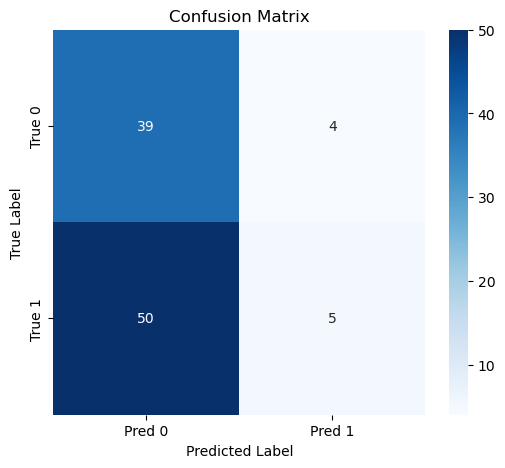

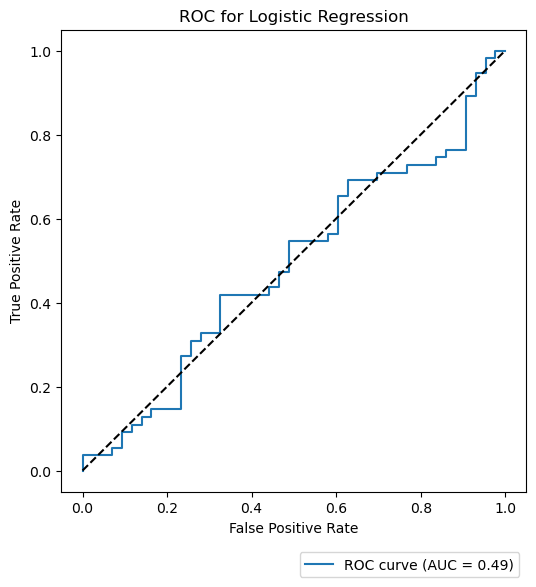

In [ ]:
#modelling with embeddings reduced to 6 dimensions and 6 nummerical columns
#initalizing umap
reducer=umap.UMAP(n_components=6, n_jobs=-1)
#reducing components
embeddings_array=np.stack(df_modelling['embeddings_vector'])
Embeddings_reduced=reducer.fit_transform(embeddings_array)
X =np.concatenate((Embeddings_reduced, numerical_values), axis=1)
print(X.shape)
print("Logistic Regression with embeddings reduced to 6 components and 6 numerical columns")
y_pred, model=get_class_report_auc_log_reg(X, LogisticRegression(),)

(490, 518)
Logistic Regression with numerical values (6) and 512 embeddings with 5 days roling window for videos
              precision    recall  f1-score   support

           0       0.50      0.50      0.50        20
           1       0.66      0.66      0.66        29

    accuracy                           0.59        49
   macro avg       0.58      0.58      0.58        49
weighted avg       0.59      0.59      0.59        49



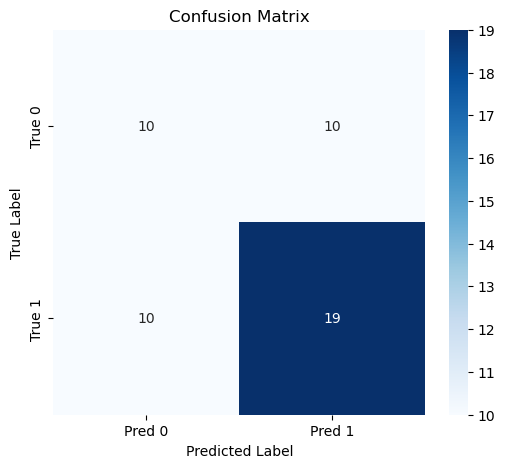

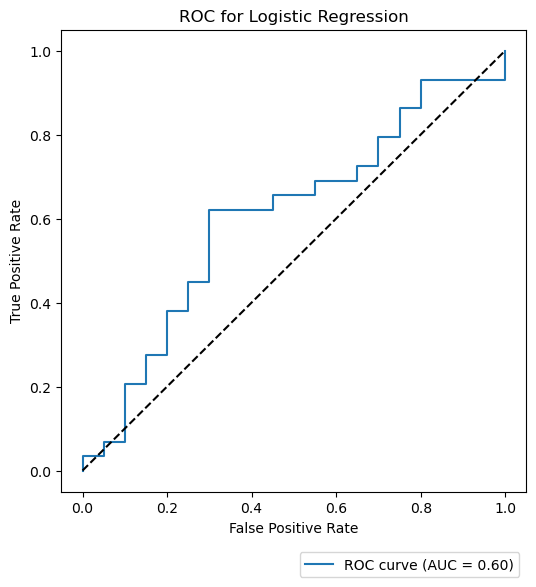

In [8]:
# Best Result Achieved in BaseLine
numerical_values=np.stack(df_modelling[numerical_columns].values)
embeddings_values=np.stack(df_modelling['embeddings_vector'].values)
X =np.concatenate((numerical_values, embeddings_values), axis=1)
print(X.shape)
print("Logistic Regression with numerical values (6) and 512 embeddings with 5 days roling window for videos")
y_pred, model=get_class_report_auc_log_reg(X, LogisticRegression())


In [ ]:
#comparing predicted versus actual
df_modelling["predicted"]=y_pred
df_modelling['Match']=df_modelling["TargetVariable:Up/Down"]==df_modelling['predicted']
df_modelling[["TargetVariable:Up/Down","Closing Price($)", "Stock_Date", "predicted", "Match"]]

,TargetVariable:Up/Down,Closing Price($),Stock_Date,predicted,Match
0,0,248.500000,2023-09-08 00:00:00-04:00,0,True
1,1,273.579987,2023-09-11 00:00:00-04:00,1,True
2,0,267.480011,2023-09-12 00:00:00-04:00,0,True
3,1,271.299988,2023-09-13 00:00:00-04:00,1,True
4,1,276.040009,2023-09-14 00:00:00-04:00,1,True
...,...,...,...,...,...
485,0,433.720001,2025-10-24 00:00:00-04:00,0,True
486,1,452.420013,2025-10-27 00:00:00-04:00,1,True
487,1,460.549988,2025-10-28 00:00:00-04:00,0,False
488,1,461.510010,2025-10-29 00:00:00-04:00,1,True


In [9]:
#saving model for later
joblib.dump(model, "best_model_baseline_logistic_regression.joblib")

['best_model_baseline_logistic_regression.joblib']